### Notebook de référence pour https://enc.hal.science/hal-05415592v1

```bibtex
@inproceedings{toumarkine:hal-05415592,
  TITLE = {{Beyond Accuracy: Investigating Vision Model Perception on 19th-Century Decorative Arts}},
  AUTHOR = {Toumarkine, Albina and Vidal-Gor{\`e}ne, Chahan},
  URL = {https://enc.hal.science/hal-05415592},
  BOOKTITLE = {{Computational Humanities Research}},
  ADDRESS = {Esch-Belval, Luxembourg},
  VOLUME = {3},
  PAGES = {1545-1563},
  YEAR = {2025},
  DOI = {10.63744/k4Jy3Lr4rdK5},
  KEYWORDS = {Zero-shot learning ; Islamic ornament 19th-century ceramics Unsupervised image analysis Feature clustering Interpretability Vision transformers Zero-shot learning ; Islamic ornament ; Vision transformers ; Interpretability ; Feature clustering ; Unsupervised image analysis ; 19th-century ceramics},
  PDF = {https://enc.hal.science/hal-05415592v1/file/Beyond_accuracy-10.63744.pdf},
  HAL_ID = {hal-05415592},
  HAL_VERSION = {v1},
}
```

In [2]:
import os, torch, faiss, cv2
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from transformers import (
    AutoImageProcessor, AutoModel,
    EfficientNetModel, ViTModel, CLIPProcessor, CLIPModel
)

dataset_dir = "images/"
result_dir = "./results_enlum"
os.makedirs(result_dir, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
# dataset
def collect_images(folder):
    return [os.path.join(folder, f) for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))]

dataset = collect_images(dataset_dir)

# embedding extractor
def extract_embeddings(model_name, dataset, batch_size=2):
    if model_name == "VGG":
        from tensorflow.keras.applications import VGG16
        from tensorflow.keras.applications.vgg16 import preprocess_input
        from tensorflow.keras.preprocessing import image
        model = VGG16(weights='imagenet', include_top=False)
        feats = []
        for path in tqdm(dataset):
            img = image.load_img(path, target_size=(224,224))
            x = np.expand_dims(image.img_to_array(img), 0)
            x = preprocess_input(x)
            f = model.predict(x, verbose=0).flatten()
            feats.append(f)
        return np.array(feats)

    elif model_name == "EfficientNet":
        processor = AutoImageProcessor.from_pretrained("google/efficientnet-b7")
        model = EfficientNetModel.from_pretrained("google/efficientnet-b7").to(device)
        model.eval()

        embs = []
        for i in tqdm(range(0, len(dataset), batch_size)):
            imgs = [Image.open(p).convert("RGB") for p in dataset[i:i+batch_size]]
            inputs = processor(images=imgs, return_tensors="pt").to(device)
            with torch.no_grad():
                out = model(**inputs, output_hidden_states=True)
                e = out.hidden_states[-1].mean(dim=[2,3])
                embs.append(e.cpu())
        return torch.cat(embs).numpy()

    elif model_name == "ViT":
        processor = AutoImageProcessor.from_pretrained("google/vit-large-patch16-224-in21k")
        model = ViTModel.from_pretrained("google/vit-large-patch16-224-in21k").to(device)
        model.eval()

        embs = []
        for i in tqdm(range(0, len(dataset), batch_size)):
            imgs = [Image.open(p).convert("RGB") for p in dataset[i:i+batch_size]]
            inputs = processor(images=imgs, return_tensors="pt").to(device)
            with torch.no_grad():
                out = model(**inputs)
                e = out.last_hidden_state[:, 0, :]
                embs.append(e.cpu())
        return torch.cat(embs).numpy()

    elif model_name == "DINOv2":
        processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
        model = AutoModel.from_pretrained("facebook/dinov2-base").to(device)
        model.eval()

        embs = []
        for i in tqdm(range(0, len(dataset), batch_size)):
            imgs = [Image.open(p).convert("RGB") for p in dataset[i:i+batch_size]]
            inputs = processor(images=imgs, return_tensors="pt").to(device)
            with torch.no_grad():
                out = model(**inputs)
                e = out.last_hidden_state[:, 0, :]
                embs.append(e.cpu())
        return torch.cat(embs).numpy()

    elif model_name == "CLIP":
        processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
        model.eval()

        embs = []
        for i in tqdm(range(0, len(dataset), batch_size)):
            imgs = [Image.open(p).convert("RGB") for p in dataset[i:i+batch_size]]
            inputs = processor(images=imgs, return_tensors="pt").to(device)
            with torch.no_grad():
                e = model.get_image_features(**inputs)
                e = torch.nn.functional.normalize(e, dim=-1)
                embs.append(e.cpu())
        return torch.cat(embs).numpy()

models = ["VGG", "EfficientNet", "ViT"] #, "ViT", "DINOv2", "CLIP"
embeddings_dict = {}

for m in models:
    npy_path = os.path.join(result_dir, f"{m}.npy")
    if os.path.exists(npy_path):
        embeddings = np.load(npy_path)
    else:
        embeddings = extract_embeddings(m, dataset)
        np.save(npy_path, embeddings)
    embeddings_dict[m] = embeddings
    print(f"{m}: {embeddings.shape}")


VGG: (200, 25088)
EfficientNet: (200, 640)
ViT: (200, 1024)


📸 200 images chargées.
✅ VGG: (200, 25088)
✅ EfficientNet: (200, 640)
✅ ViT: (200, 1024)
VGG: 0 clusters, 200 outliers
EfficientNet: 2 clusters, 44 outliers
ViT: 2 clusters, 102 outliers


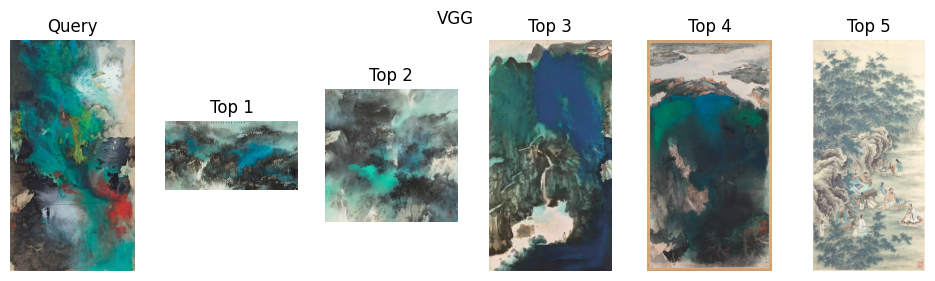

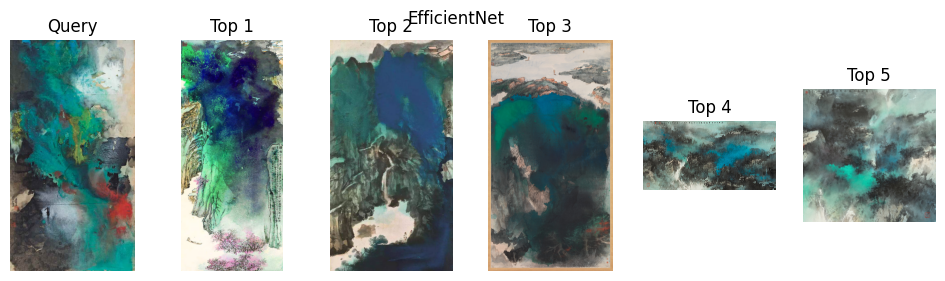

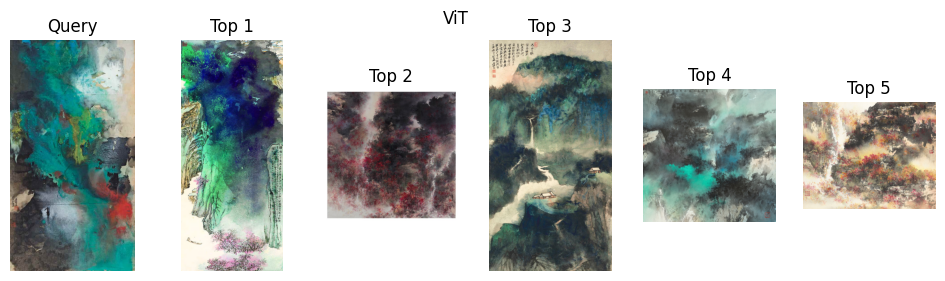

In [3]:
import os, faiss, cv2
import numpy as np, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import hdbscan

dataset_dir = "images/"
result_dir = "./results_enlum"
models = ["VGG", "EfficientNet", "ViT"]

def collect_images(folder):
    return [os.path.join(folder, f) for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))]

dataset = collect_images(dataset_dir)
print(f"📸 {len(dataset)} images chargées.")

embeddings_dict = {}
for m in models:
    npy_path = os.path.join(result_dir, f"{m}.npy")
    if not os.path.exists(npy_path):
        print(f"⚠️  Fichier manquant : {npy_path}")
        continue
    emb = np.load(npy_path)
    embeddings_dict[m] = emb
    print(f"✅ {m}: {emb.shape}")


# def cluster_embeddings(embeddings, n_clusters=5):
#     pca = PCA(n_components=min(50, embeddings.shape[1]))
#     reduced = pca.fit_transform(embeddings)
#     kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
#     labels = kmeans.fit_predict(reduced)
#     return labels, reduced


# def cluster_embeddings(embeddings, eps=0.5, min_samples=5):
#     pca = PCA(n_components=min(50, embeddings.shape[1]))
#     reduced = pca.fit_transform(embeddings)
#     clustering = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
#     labels = clustering.fit_predict(reduced)
#     return labels, reduced


def cluster_embeddings(embeddings, min_cluster_size=10):
    pca = PCA(n_components=min(50, embeddings.shape[1]))
    reduced = pca.fit_transform(embeddings)
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=5)
    labels = clusterer.fit_predict(reduced)
    return labels, reduced

cluster_results = {}
for m, emb in embeddings_dict.items():
    labels, reduced = cluster_embeddings(emb, min_cluster_size=10)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"{m}: {n_clusters} clusters, {np.sum(labels==-1)} outliers")


def faiss_index_search(embeddings, query_idx=0, k=6):
    vecs = embeddings.astype(np.float32)
    faiss.normalize_L2(vecs)
    index = faiss.IndexFlatIP(vecs.shape[1])
    index.add(vecs)
    q = vecs[query_idx:query_idx+1]
    D, I = index.search(q, k)
    return I[0]

def show_similar_images(model_name, query_idx=0):
    emb = embeddings_dict[model_name]
    idxs = faiss_index_search(emb, query_idx)
    plt.figure(figsize=(12, 3))
    for i, idx in enumerate(idxs):
        img = cv2.imread(dataset[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, len(idxs), i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title("Query" if i == 0 else f"Top {i}")
    plt.suptitle(model_name)
    plt.show()

query_idx = 123  # image de référence
for m in models:
    if m in embeddings_dict:
        show_similar_images(m, query_idx)


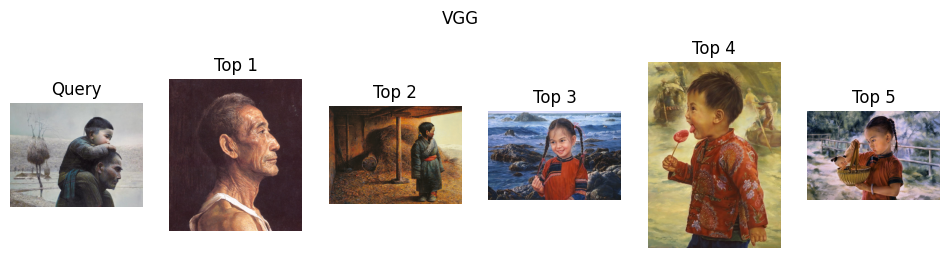

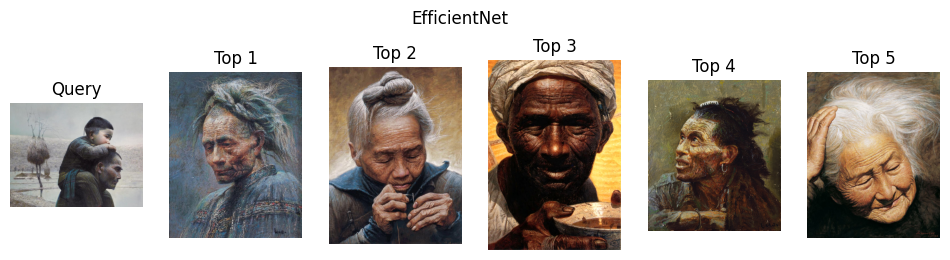

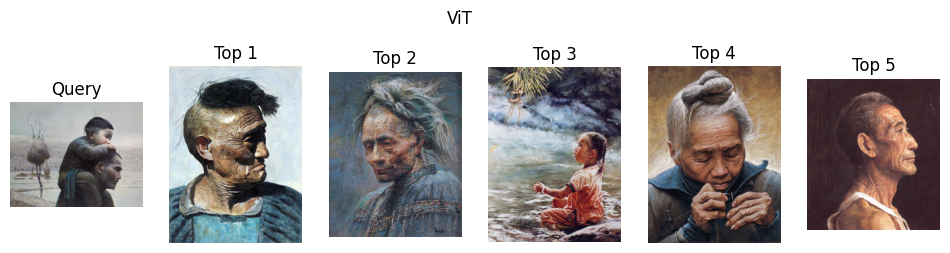

In [4]:
query_idx = 156  # image de référence
for m in models:
    if m in embeddings_dict:
        show_similar_images(m, query_idx)

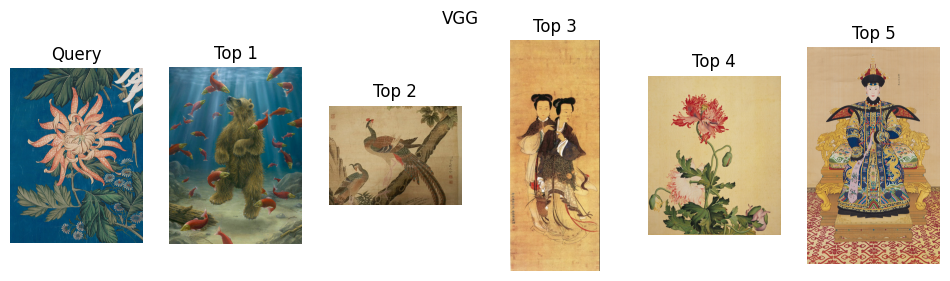

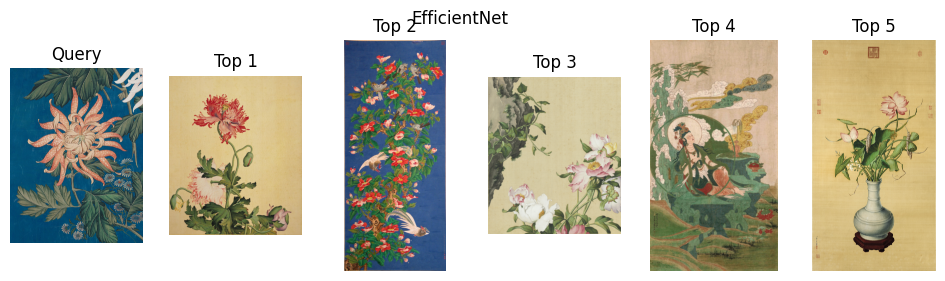

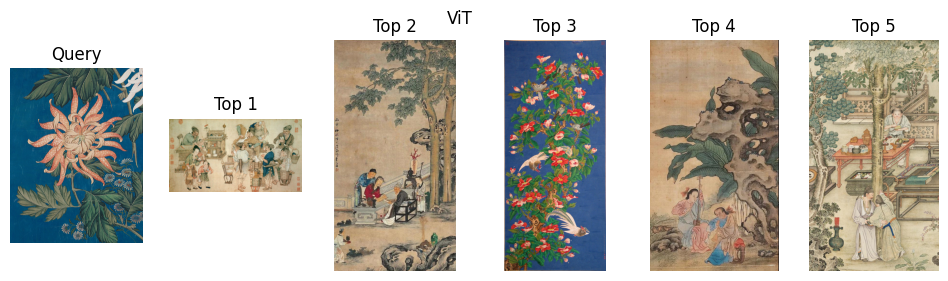

In [5]:
query_idx = 0  # image de référence
for m in models:
    if m in embeddings_dict:
        show_similar_images(m, query_idx)

In [1]:
import os, cv2, faiss, torch
import numpy as np, matplotlib.pyplot as plt
from PIL import Image
from transformers import (
    AutoImageProcessor, EfficientNetModel,
    ViTModel, CLIPProcessor, CLIPModel
)
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image


os.makedirs("results_heatmaps", exist_ok=True)
os.makedirs("results_crops", exist_ok=True)

def compute_heatmap(model_name, img, np_img, device):
    if model_name == "VGG":
        model = VGG16(weights='imagenet', include_top=False)
        x = np.expand_dims(keras_image.img_to_array(img), 0)
        x = preprocess_input(x)
        feat = model.predict(x, verbose=0)[0]
        heatmap = np.mean(feat, axis=-1)

    elif model_name == "EfficientNet":
        processor = AutoImageProcessor.from_pretrained("google/efficientnet-b7")
        model = EfficientNetModel.from_pretrained("google/efficientnet-b7").to(device)
        inputs = processor(images=img, return_tensors="pt").to(device)
        with torch.no_grad():
            out = model(**inputs, output_hidden_states=True)
            feat = out.hidden_states[-1][0].cpu().numpy()
            heatmap = np.mean(feat, axis=0)

    elif model_name == "ViT":
        processor = AutoImageProcessor.from_pretrained("google/vit-large-patch16-224-in21k")
        model = ViTModel.from_pretrained("google/vit-large-patch16-224-in21k").to(device)
        inputs = processor(images=img, return_tensors="pt").to(device)
        with torch.no_grad():
            out = model(**inputs, output_hidden_states=True)
            attn = out.last_hidden_state[0, 1:, :].mean(-1)
            side = int(attn.shape[0] ** 0.5)
            heatmap = attn.reshape(side, side).cpu().numpy()

    elif model_name == "CLIP":
        processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
        inputs = processor(images=img, return_tensors="pt").to(device)
        with torch.no_grad():
            out = model.vision_model(**inputs, output_hidden_states=True)
            feat = out.last_hidden_state[0, 1:, :].mean(-1)
            side = int(feat.shape[0] ** 0.5)
            heatmap = feat.reshape(side, side).cpu().numpy()

    else:
        raise ValueError(f"Modèle {model_name} non supporté")

    heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap) + 1e-8)
    heatmap = cv2.resize(heatmap, (np_img.shape[1], np_img.shape[0]))
    return heatmap

def compare_heatmaps(image_path, models=["VGG", "EfficientNet", "ViT"]):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    img = Image.open(image_path).convert("RGB").resize((224, 224))
    np_img = np.array(img)

    fig, axes = plt.subplots(1, len(models), figsize=(4.5 * len(models), 5))
    if len(models) == 1:
        axes = [axes]

    for ax, model_name in zip(axes, models):
        heatmap = compute_heatmap(model_name, img, np_img, device)
        color = cv2.applyColorMap((heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET)
        overlay = cv2.addWeighted(cv2.cvtColor(np_img, cv2.COLOR_RGB2BGR), 0.6, color, 0.4, 0)
        ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        ax.set_title(model_name)
        ax.axis("off")

    plt.suptitle(f"Comparaison des heatmaps pour {os.path.basename(image_path)}", fontsize=14)
    plt.tight_layout()
    plt.show()

def extract_hot_crop(np_img, heatmap, crop_size=100):
    """Renvoie un crop centré sur la zone la plus activée."""
    y, x = np.unravel_index(np.argmax(heatmap), heatmap.shape)
    h, w = np_img.shape[:2]
    y1 = max(y - crop_size // 2, 0)
    y2 = min(y1 + crop_size, h)
    x1 = max(x - crop_size // 2, 0)
    x2 = min(x1 + crop_size, w)
    return np_img[y1:y2, x1:x2]


def show_faiss_similarity_multimodel(models, embeddings_dict, dataset,
                                     query_idx=0, top_k=3, crop_size=100):
    device = "cpu" if torch.cuda.is_available() else "cpu"
    query_path = dataset[query_idx]
    query_img = Image.open(query_path).convert("RGB").resize((224, 224))
    np_q = np.array(query_img)

    fig, axes = plt.subplots(len(models), top_k + 1,
                             figsize=(3 * (top_k + 1), 4 * len(models)))

    # Pour chaque modèle
    for i, model_name in enumerate(models):
        emb = embeddings_dict[model_name].astype(np.float32)
        faiss.normalize_L2(emb)
        index = faiss.IndexFlatIP(emb.shape[1])
        index.add(emb)
        D, I = index.search(emb[query_idx:query_idx + 1], top_k + 1)
        sim_paths = [dataset[j] for j in I[0]]

        # Query
        heat_q = compute_heatmap(model_name, query_img, np_q, device)
        color_q = cv2.applyColorMap((heat_q * 255).astype(np.uint8), cv2.COLORMAP_JET)
        overlay_q = cv2.addWeighted(cv2.cvtColor(np_q, cv2.COLOR_RGB2BGR), 0.6, color_q, 0.4, 0)
        axes[i, 0].imshow(cv2.cvtColor(overlay_q, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f"{model_name}\nQuery")
        axes[i, 0].axis("off")

        # Crop zone la plus chaude
        crop_q = extract_hot_crop(np_q, heat_q, crop_size)
        crop_path = f"results_crops/{model_name}_query_crop_{os.path.basename(query_path)}"
        cv2.imwrite(crop_path, cv2.cvtColor(crop_q, cv2.COLOR_RGB2BGR))

        # Similaires
        for k in range(1, top_k + 1):
            sim_path = sim_paths[k]
            img_s = Image.open(sim_path).convert("RGB").resize((224, 224))
            np_s = np.array(img_s)
            heat_s = compute_heatmap(model_name, img_s, np_s, device)
            color_s = cv2.applyColorMap((heat_s * 255).astype(np.uint8), cv2.COLORMAP_JET)
            overlay_s = cv2.addWeighted(cv2.cvtColor(np_s, cv2.COLOR_RGB2BGR), 0.6, color_s, 0.4, 0)
            axes[i, k].imshow(cv2.cvtColor(overlay_s, cv2.COLOR_BGR2RGB))
            axes[i, k].set_title(f"Top {k}")
            axes[i, k].axis("off")

            crop_s = extract_hot_crop(np_s, heat_s, crop_size)
            crop_path = f"results_crops/{model_name}_top{k}_crop_{os.path.basename(sim_path)}"
            cv2.imwrite(crop_path, cv2.cvtColor(crop_s, cv2.COLOR_RGB2BGR))

    plt.suptitle(
        f"Comparaison multi-modèles — Top{top_k} similaires\nQuery = {os.path.basename(query_path)}",
        fontsize=14)
    plt.tight_layout()

    fig_path = f"results_heatmaps/heatmap_{os.path.basename(query_path)}.png"
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"✅ Figure sauvegardée dans {fig_path}")
    print(f"✅ Crops sauvegardés dans results_crops/")

/home/chahan/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-05 13:13:29.021484: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1770293622.543211  119949 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22461 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:08:00.0, compute capability: 8.6
2026-02-05 13:13:43.893016: I external/local_xla/xla/service/service.cc:163] XLA service 0x7faf1c0057f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-05 13:13:43.893038: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2026-02-05 13:13:43.906661: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-05 13:13:43.985648: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
I0000 00:00:1770293624.714684  120080 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at mo

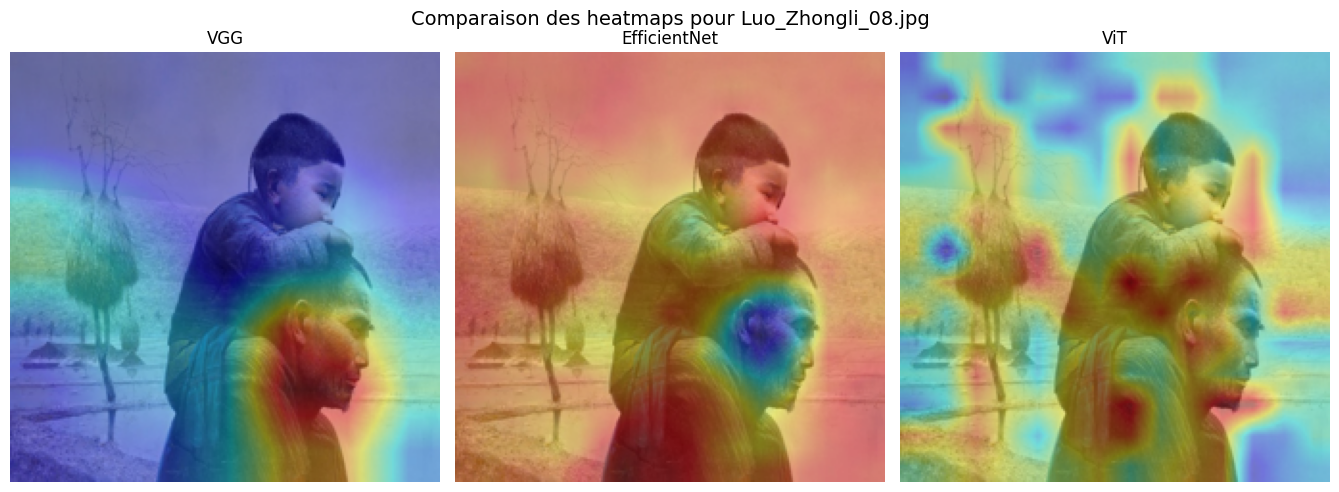

In [4]:
compare_heatmaps(dataset[156])

Loading weights: 100%|██████████| 1198/1198 [00:01<00:00, 1035.02it/s, Materializing param=encoder.top_conv.weight]                                            
EfficientNetModel LOAD REPORT from: google/efficientnet-b7
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 1198/1198 [00:00<00:00, 1473.88it/s, Materializing param=encoder.top_conv.weight]                                            
EfficientNetModel LOAD REPORT from: google/efficientnet-b7
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██

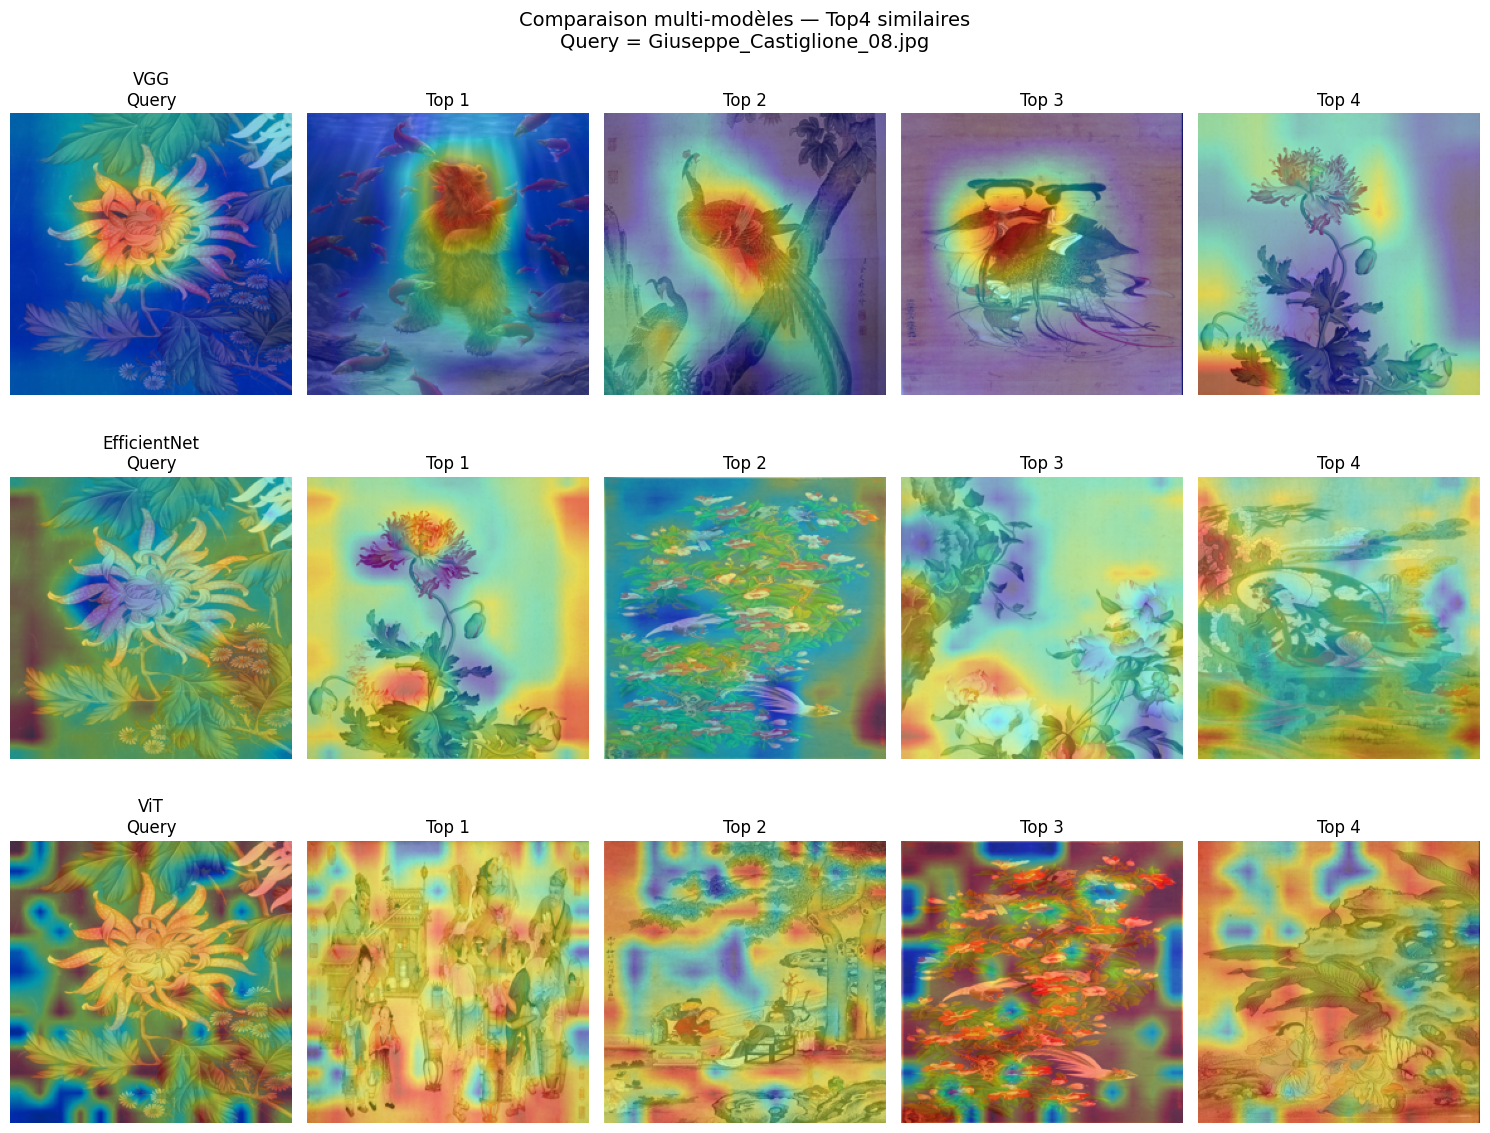

✅ Figure sauvegardée dans results_heatmaps/heatmap_Giuseppe_Castiglione_08.jpg.png
✅ Crops sauvegardés dans results_crops/


In [5]:
models = ["VGG", "EfficientNet", "ViT"]
show_faiss_similarity_multimodel(models, embeddings_dict, dataset, query_idx=0, top_k=4)


In [7]:
!pip install umap

ERROR: Could not find a version that satisfies the requirement umap (from versions: none)

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for umap


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import umap.umap_ as umap
import hdbscan
from sklearn.preprocessing import StandardScaler
from PIL import Image

result_dir = "./results_models"
dataset_dir = "/mnt/chahan/albina-chr_obj_imgs_cleaned"
model_name = "VGG"

embeddings = np.load(os.path.join(result_dir, f"{model_name}.npy"))
image_paths = np.array([
    os.path.join(dataset_dir, f)
    for f in os.listdir(dataset_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

# Réduction UMAP
X = StandardScaler().fit_transform(embeddings)
reducer = umap.UMAP(n_neighbors=20, min_dist=0.1, metric='cosine', random_state=42)
X_umap = reducer.fit_transform(X)

# Clustering HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=25, metric='euclidean')
labels = clusterer.fit_predict(X_umap)

unique_labels = np.unique(labels[labels >= 0])
print(f"✅ {len(unique_labels)} motifs dominants trouvés.")
print(f"❌ {np.sum(labels == -1)} images isolées (outliers)")

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap="tab20", s=10)
plt.title(f"{model_name} — Carte des motifs visuels (UMAP + HDBSCAN)")
plt.axis("off")
plt.show()

def get_cluster_prototypes(labels, X, image_paths, n_samples=6):
    prototypes = {}
    for c in np.unique(labels):
        if c == -1:
            continue
        idxs = np.where(labels == c)[0]
        center = X[idxs].mean(axis=0)
        dists = np.linalg.norm(X[idxs] - center, axis=1)
        top_idxs = idxs[np.argsort(dists)[:n_samples]]
        prototypes[c] = [image_paths[i] for i in top_idxs]
    return prototypes

prototypes = get_cluster_prototypes(labels, X_umap, image_paths)

def show_cluster_prototypes(prototypes, n_cols=6, size=2.5):
    n_clusters = len(prototypes)
    plt.figure(figsize=(n_cols*size, n_clusters*size))
    
    for i, (c, imgs) in enumerate(prototypes.items()):
        for j, path in enumerate(imgs[:n_cols]):
            img = Image.open(path).convert("RGB").resize((128, 128))
            ax = plt.subplot(n_clusters, n_cols, i*n_cols + j + 1)
            ax.imshow(img)
            ax.axis("off")
            if j == 0:
                ax.set_title(f"Motif #{c}", fontsize=10)
    plt.suptitle("Prototypes des motifs visuels dominants", fontsize=14)
    plt.tight_layout()
    plt.show()

show_cluster_prototypes(prototypes)


ModuleNotFoundError: No module named 'umap'

In [ ]:
import os, cv2, torch
import numpy as np, matplotlib.pyplot as plt
import umap.umap_ as umap, hdbscan
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from PIL import Image
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image
from transformers import (
    AutoImageProcessor, ViTModel,
    CLIPProcessor, CLIPModel
)

dataset_dir = "/mnt/chahan/albina-chr_obj_imgs_cleaned"
image_paths = [
    os.path.join(dataset_dir, f)
    for f in os.listdir(dataset_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
][:200]  # limite pour test

device = "cuda" if torch.cuda.is_available() else "cpu"

def extract_vgg_features(img_path):
    model = VGG16(weights="imagenet", include_top=False)
    layer_model = model.get_layer("block4_conv3").output
    from tensorflow.keras.models import Model
    extractor = Model(inputs=model.input, outputs=layer_model)
    img = keras_image.load_img(img_path, target_size=(224, 224))
    x = np.expand_dims(keras_image.img_to_array(img), 0)
    x = preprocess_input(x)
    feat = extractor.predict(x, verbose=0)[0]
    return feat  # (14,14,512)

def extract_vit_features(img_path):
    processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")
    model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k").to(device)
    model.eval()
    img = Image.open(img_path).convert("RGB")
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(**inputs)
    tokens = out.last_hidden_state[0, 1:, :].cpu().numpy()  # (196,768)
    return tokens.reshape(14, 14, -1)

def extract_clip_features(img_path):
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
    model.eval()
    img = Image.open(img_path).convert("RGB")
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.vision_model(**inputs, output_hidden_states=True)
    feats = out.last_hidden_state[0, 1:, :].cpu().numpy()  # (49,512)
    return feats.reshape(7, 7, -1)

def extract_features(model_name, paths):
    feats_all, pos_all, src_all = [], [], []
    for path in tqdm(paths, desc=f"{model_name} features"):
        try:
            if model_name == "VGG":
                fmap = extract_vgg_features(path)
                stride = 2
            elif model_name == "ViT":
                fmap = extract_vit_features(path)
                stride = 1
            elif model_name == "CLIP":
                fmap = extract_clip_features(path)
                stride = 1
            else:
                continue

            h, w, c = fmap.shape
            for i in range(0, h, stride):
                for j in range(0, w, stride):
                    feats_all.append(fmap[i, j, :])
                    pos_all.append((i, j))
                    src_all.append(path)
        except Exception as e:
            print(f"⚠️ {path}: {e}")
    return np.array(feats_all), pos_all, src_all

def analyze_model(model_name, paths):
    feats, pos, src = extract_features(model_name, paths)
    print(f"{model_name}: {feats.shape}")

    # UMAP
    X = StandardScaler().fit_transform(feats)
    reducer = umap.UMAP(n_neighbors=20, min_dist=0.1, metric="cosine", random_state=42)
    X_umap = reducer.fit_transform(X)

    # Clustering
    clusterer = hdbscan.HDBSCAN(min_cluster_size=30, metric="euclidean")
    labels = clusterer.fit_predict(X_umap)
    n_clusters = len(np.unique(labels[labels >= 0]))
    print(f"✅ {model_name}: {n_clusters} motifs trouvés")

    # Visualisation 2D
    plt.figure(figsize=(7, 6))
    plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap="tab20", s=4)
    plt.title(f"{model_name} — Carte des motifs visuels")
    plt.axis("off")
    plt.show()

    return labels, pos, src

# Visualisation des patchs
def visualize_clusters(labels, patch_sources, patch_positions, model_name, n_samples=8):
    unique_clusters = np.unique(labels)
    for c in unique_clusters:
        if c == -1:
            continue
        idxs = np.where(labels == c)[0]
        if len(idxs) < n_samples:
            continue
        chosen = np.random.choice(idxs, size=min(n_samples, len(idxs)), replace=False)
        plt.figure(figsize=(12, 2))
        for k, idx in enumerate(chosen):
            path = patch_sources[idx]
            img = cv2.imread(path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w, _ = img.shape
            i, j = patch_positions[idx]
            scale = 16 if model_name == "VGG" else (32 if model_name == "CLIP" else 16)
            y1, y2 = max(0, i * scale), min(h, i * scale + 32)
            x1, x2 = max(0, j * scale), min(w, j * scale + 32)
            crop = img[y1:y2, x1:x2]
            if crop.size == 0:
                continue
            plt.subplot(1, n_samples, k + 1)
            plt.imshow(crop)
            plt.axis("off")
        plt.suptitle(f"{model_name} — Motif #{c} ({len(idxs)} occurrences)")
        plt.show()

for model in ["VGG", "ViT", "CLIP"]:
    labels, pos, src = analyze_model(model, image_paths)
    visualize_clusters(labels, src, pos, model)


In [ ]:
import os, cv2, numpy as np, matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap, hdbscan
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.models import Model

dataset_dir = "/mnt/chahan/albina-chr_obj_imgs_cleaned"
image_paths = [
    os.path.join(dataset_dir, f)
    for f in os.listdir(dataset_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
][:200]  # limite pour test

def extract_multilayer_vgg_features(img_path):
    base = VGG16(weights="imagenet", include_top=False)
    layers = ["block3_conv3", "block4_conv3", "block5_conv3"]
    outputs = [base.get_layer(l).output for l in layers]
    model = Model(inputs=base.input, outputs=outputs)

    img = keras_image.load_img(img_path, target_size=(224, 224))
    x = np.expand_dims(keras_image.img_to_array(img), 0)
    x = preprocess_input(x)

    f3, f4, f5 = model.predict(x, verbose=0)

    # Vérifie et redimensionne proprement vers 14x14
    def safe_resize(feat, target=(14, 14)):
        if feat.ndim == 4: feat = feat[0]
        if feat.shape[:2] != target:
            feat = cv2.resize(feat.mean(-1), target, interpolation=cv2.INTER_LINEAR)
        else:
            feat = feat.mean(-1)
        return feat

    f3r = safe_resize(f3)
    f4r = safe_resize(f4)
    f5r = safe_resize(f5)

    # Force la cohérence finale
    f3r, f4r, f5r = [np.resize(f, (14, 14)) for f in (f3r, f4r, f5r)]

    combined = np.stack([f3r, f4r, f5r], axis=-1).astype(np.float32)
    feat = combined.reshape(-1, 3)
    return feat


feats_all, pos_all, src_all = [], [], []
for path in tqdm(image_paths, desc="VGG multi-layer"):
    try:
        fmap = extract_multilayer_vgg_features(path)
        h = w = 14
        for i in range(h):
            for j in range(w):
                feats_all.append(fmap[i * w + j])
                pos_all.append((i, j))
                src_all.append(path)
    except Exception as e:
        print(f"⚠️ {path}: {e}")

feats_all = np.array(feats_all)
print("Total features:", feats_all.shape)

norms = np.linalg.norm(feats_all, axis=1)
mask = norms > np.percentile(norms, 70)
feats_all = feats_all[mask]
pos_all = [pos_all[i] for i in range(len(mask)) if mask[i]]
src_all = [src_all[i] for i in range(len(mask)) if mask[i]]
print("Filtrées:", feats_all.shape)

# UMAP + Clustering
X = StandardScaler().fit_transform(feats_all)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
X_umap = reducer.fit_transform(X)

clusterer = hdbscan.HDBSCAN(min_cluster_size=30, metric="euclidean")
labels = clusterer.fit_predict(X_umap)
n_clusters = len(np.unique(labels[labels >= 0]))
print(f"✅ VGG multi-layer: {n_clusters} motifs trouvés")

plt.figure(figsize=(7, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap="tab20", s=5)
plt.title("VGG (multi-couches) — Carte des motifs visuels")
plt.axis("off")
plt.show()

def visualize_clusters(labels, patch_sources, patch_positions, n_samples=8):
    for c in np.unique(labels):
        if c == -1:
            continue
        idxs = np.where(labels == c)[0]
        if len(idxs) < n_samples:
            continue
        chosen = np.random.choice(idxs, size=min(n_samples, len(idxs)), replace=False)
        plt.figure(figsize=(12, 2))
        for k, idx in enumerate(chosen):
            path = patch_sources[idx]
            img = cv2.imread(path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w, _ = img.shape
            i, j = patch_positions[idx]
            y1, y2 = max(0, i * 16), min(h, i * 16 + 32)
            x1, x2 = max(0, j * 16), min(w, j * 16 + 32)
            crop = img[y1:y2, x1:x2]
            if crop.size == 0:
                continue
            plt.subplot(1, n_samples, k + 1)
            plt.imshow(crop)
            plt.axis("off")
        plt.suptitle(f"Motif #{c} ({len(idxs)} occurrences)")
        plt.show()

visualize_clusters(labels, src_all, pos_all)
